# batss Python package

The `batss` package (**bat**ched **s**tochastic **s**imulator) simulates stochastic chemical reaction
networks (CRNs). The package and further example notebooks can be found on
[Github](https://github.com/UC-Davis-molecular-computing/batss).

If you find batss useful in a scientific project, please cite its associated paper:

> <ins>Exactly simulating stochastic chemical reaction networks in sub-constant time per reaction</ins>.  
  Joshua Petrack and David Doty.  
  preprint  
  [ [paper](https://arxiv.org/abs/2508.04079) | [BibTeX](README_files/bibtex.txt) ]

Most stochastic CRN simulators use the Gillespie algorithm, which simulates one reaction at a time, so the
work needed to simulate a fixed span of time grows linearly with the population size $n$. batss instead uses
a *batching* algorithm — inspired by a [batching algorithm](https://arxiv.org/abs/2005.03584) for population
protocols and adapted to general CRNs — that samples many reactions at once, taking sub-constant time per
reaction. This makes large populations (billions of molecules, and beyond) practical. It falls back to
Gillespie whenever that would be faster, so it is never much slower.

Crucially, batching is **exact**, not an approximation: it samples from precisely the same distribution as
the Gillespie algorithm, unlike approximate methods such as tau-leaping.

The package is designed to be used in a Python notebook, to concisely describe a CRN, efficiently simulate
its dynamics, and help visualize the result. This notebook is the source of
[README.md](https://github.com/UC-Davis-molecular-computing/batss#readme) — you can download it and run
every example below.

## Table of contents

* [Installation](#installation)
* [Describing a CRN](#describing-a-crn)
* [Simulating](#simulating)
* [Plotting the history](#plotting-the-history)
* [Larger populations](#larger-populations)
* [Running until a condition](#running-until-a-condition)
* [Long runs and log-spaced sampling](#long-runs-and-log-spaced-sampling)
* [Visualizing a single configuration](#visualizing-a-single-configuration)
* [Live visualization](#live-visualization)
* [Sampling the distribution](#sampling-the-distribution)
* [Time units](#time-units)
* [More examples](#more-examples)

## Installation

The package can be installed with `pip` via

```bash
pip install batss
```

## Describing a CRN

We will use the [Lotka-Volterra](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations)
predator-prey oscillator as a running example: rabbits $R$ breed, foxes $F$ eat rabbits and breed, and foxes
starve.

$$\begin{aligned}
R &\to 2R,\\
R + F &\to 2F,\\
F &\to \emptyset.
\end{aligned}$$

Start by declaring the species. `species` takes a whitespace-separated string of names and returns one
object per name.

In [1]:
from batss import species, Simulation

r, f = species('R F')

batss overloads Python's operators so that a reaction looks like a reaction: `>>` separates reactants from
products, `+` combines species, `2*r` gives a stoichiometric coefficient, and `None` on the product side
means the reaction has no products ($\emptyset$).

In [2]:
rxns = [
    r >> 2*r,
    r + f >> 2*f,
    f >> None,
]

for rxn in rxns:
    print(rxn)

R -->(1.0) R + R
R + F -->(1.0) F + F
F -->(1.0) 


Rate constants default to 1. `.k(...)` sets the rate constant, `|` makes a reaction reversible, and
`.r(...)` sets the reverse rate constant. These chain, so the reversible reaction
$A + B \underset{4}{\overset{0.5}{\rightleftharpoons}} 2C$ is written as follows. (This one is just an
illustration; we go back to Lotka-Volterra below.)

In [3]:
a, b, c = species('A B C')

print((a + b | 2*c).k(0.5).r(4))

A + B (4)<-->(0.5) C + C


## Simulating

`Simulation` is the central object: it parses the reactions, runs the simulation, and holds the resulting
data. It takes a dict of initial molecular counts, plus the reactions.

Rate constants use the standard mass-action convention, so a reaction with $k$ reactants has its rate
constant divided by `volume ** (k-1)`. By default `volume` is the total initial count $n$, which is usually
what you want: it keeps the time scale independent of the population size, so the same reactions oscillate
at the same rate whether you simulate $10^4$ molecules or $10^{10}$. (Pass `volume=...` explicitly if the
initial counts should not define the volume.)

Let's start with ten million molecules, split evenly between rabbits and foxes.

In [4]:
n = 10 ** 7
sim = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=0)
sim.run(10.0, 0.01)

  0%|          | 0/10.0 [00:00<?, ? time simulated/s]

That simulated 10 units of continuous time, recording the configuration every 0.01 time units. It is worth
appreciating what just happened: with $n = 10^7$ molecules reacting for 10 time units, that is on the order
of $10^8$ individual reactions, simulated exactly, in a couple of seconds.

Every recorded configuration lives in `sim.history`, a pandas `DataFrame` indexed by time.

In [5]:
sim.history

,F,R
time (continuous units),,
0.00,5000000,5000000
0.01,4975459,5025151
0.02,4950955,5050925
0.03,4926732,5076241
0.04,4902957,5102584
...,...,...
9.96,16445246,18575403
9.97,16586894,18454077
9.98,16727608,18330929


`print(sim.reactions)` shows the reactions back, which is a quick way to check that batss parsed them the
way you intended.

In [6]:
print(sim.reactions)

R -->(1.0) R + R
R + F -->(1.0) F + F
F -->(1.0) 


## Plotting the history

Because `history` is an ordinary `DataFrame`, all of pandas' plotting works directly on it.

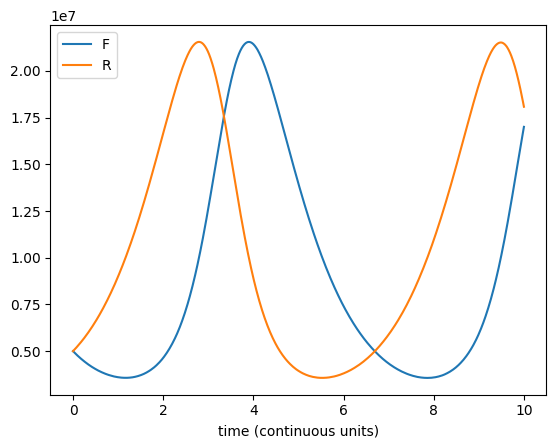

In [7]:
p = sim.history.plot()

The two populations chase each other around a cycle: rabbits boom, foxes eat well and boom in turn, the
rabbits crash, and then the foxes starve.

That structure is clearer in the *phase plane*, plotting the two counts against each other rather than
against time. The deterministic Lotka-Volterra ODE has closed orbits, which would give an exactly repeating
loop; the stochastic CRN instead spirals slowly outward, and it is this outward drift that eventually drives
a species extinct (we come back to that below).

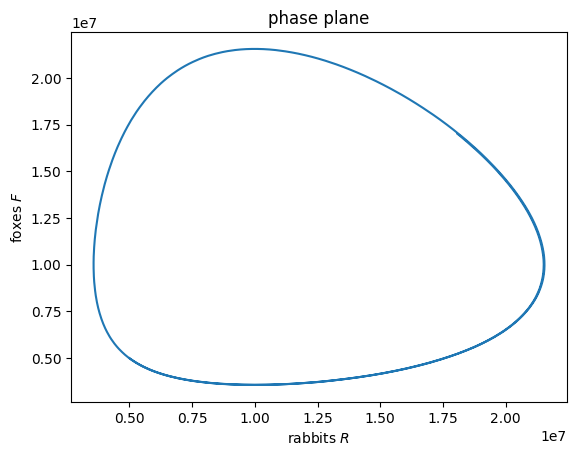

In [8]:
ax = sim.history.plot(x='R', y='F', legend=False)
ax.set_xlabel('rabbits $R$')
ax.set_ylabel('foxes $F$')
p = ax.set_title('phase plane')

## Larger populations

Batching exists so that this stays fast as $n$ grows. Here is the very same CRN with **one billion**
molecules — around $10^{10}$ individual reactions, which a Gillespie simulator would have to step through
one at a time.

  0%|          | 0/10.0 [00:00<?, ? time simulated/s]

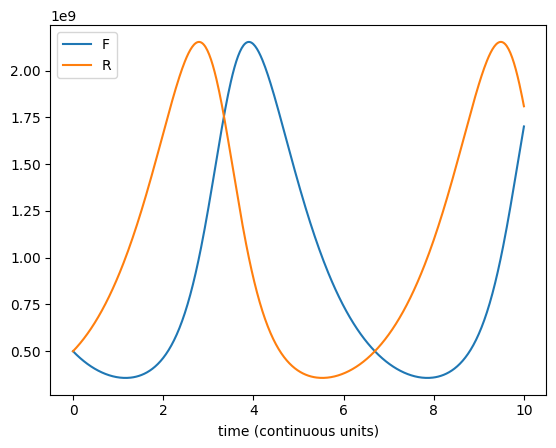

In [9]:
n = 10 ** 9
big = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=0)
big.run(10.0, 0.02)
p = big.history.plot()

The trajectory is visibly smoother than at $n = 10^7$. Stochastic fluctuations scale like $\sqrt{n}$ while
the counts themselves scale like $n$, so the *relative* noise shrinks as $\sqrt{1/n}$ and the CRN behaves
more and more like its deterministic limit.

## Running until a condition

Instead of a fixed end time, `run_until` accepts a *convergence detector*: any function taking the current
configuration (a dict mapping species to counts) and returning a bool. The simulation runs until it returns
`True`.

Lotka-Volterra is a nice example, because the stochastic model does something the deterministic one never
does. The ODE cycles forever, but at any finite $n$ the outward spiral we saw above eventually overshoots,
one species undershoots to zero, and it is gone for good.

In [10]:
def one_species_extinct(config):
    return config.get(r, 0) == 0 or config.get(f, 0) == 0


n = 1000
small = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=0)
small.run(one_species_extinct, 0.05)

print(f'extinction at time {small.time:.0f}')
print(small.config_dict)

0 time simulated [00:00, ? time simulated/s]

extinction at time 1148
{R: 33}


**A word of warning.** Calling `run()` with no arguments runs until the configuration is *silent*, meaning
no reaction can occur at all. For Lotka-Volterra that is not safe: if the foxes die out first, then nothing
stops $R \to 2R$, the rabbits breed without bound, and the configuration is never silent — so `run()` would
never return. Use a convergence detector whenever silence is not guaranteed.

The extinction itself is invisible on a linear axis: the counts fall through several orders of magnitude in
the last few oscillations, and everything below a few hundred is squashed onto the $x$-axis. Matplotlib's
`symlog` scale (linear near zero, logarithmic above it) shows the whole descent. Here are the last 120 time
units, where the oscillations grow until one species finally undershoots to zero.

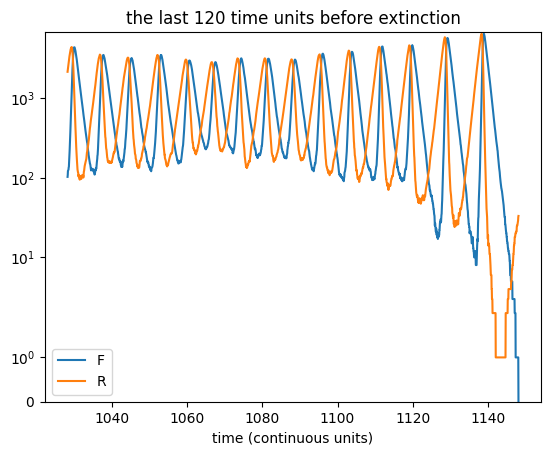

In [11]:
endgame = small.history.loc[small.time - 120:]

ax = endgame.plot()
ax.set_yscale('symlog')
ax.set_ylim(bottom=0)   # symlog would otherwise show a meaningless negative range
p = ax.set_title('the last 120 time units before extinction')

## Long runs and log-spaced sampling

We did not know in advance how long that run would take, and with a fixed `history_interval` a long run
records a great many nearly identical configurations. `history_interval` may instead be a *function of the
current time*, so that recording gets steadily coarser as the simulation goes on — keeping the history to a
manageable size without losing detail early on, when things are changing fastest.

In [12]:
coarse = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=0)
coarse.run(one_species_extinct, history_interval=lambda t: max(0.05, t / 200))

print(f'{len(coarse.history)} configurations recorded, '
      f'vs {len(small.history)} for the fixed interval above')

0 time simulated [00:00, ? time simulated/s]

1148 configurations recorded, vs 22964 for the fixed interval above


## Visualizing a single configuration

Each row of `sim.history` is one configuration, so a single row can be drawn as a barplot. Here is the
$n = 10^7$ simulation at two different times.

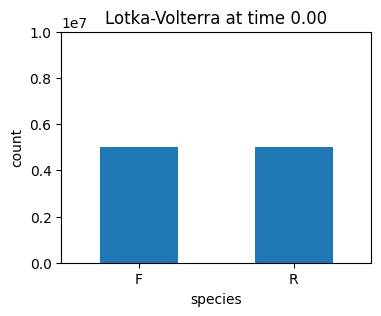

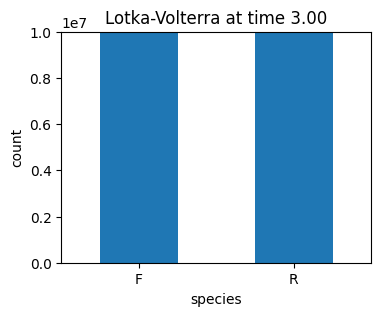

In [13]:
from matplotlib import pyplot as plt


def plot_row(row):
    fig, ax = plt.subplots(figsize=(4, 3))
    sim.history.iloc[row].plot(
        ax=ax, kind='bar', ylim=(0, sim.n), rot=0, xlabel='species', ylabel='count',
        title=f'Lotka-Volterra at time {sim.history.index[row]:.2f}')


plot_row(0)
plot_row(300)

`ipywidgets` turns that into a slider that scrubs through the whole history.

In [14]:
import ipywidgets as widgets

bar = widgets.interact(plot_row, row=widgets.IntSlider(
    min=0, max=len(sim.history) - 1, step=1, value=0, layout=widgets.Layout(width='100%')))

interactive(children=(IntSlider(value=0, description='row', layout=Layout(width='100%'), max=1000), Output()),…

## Live visualization

Everything above plots *after* the simulation finishes. A `Snapshot` plots *while it runs*: `StatePlotter`
is a barplot of the current configuration and `HistoryPlotter` is a line plot of the history so far.
`sim.add_snapshot(...)` attaches one, and it then redraws periodically during `run`.

To actually watch these update live, you need an interactive matplotlib backend: `pip install ipympl`, then
put `%matplotlib widget` at the top of the notebook. [Jupyter Lab](https://jupyterlab.readthedocs.io) is the
recommended environment; unfortunately Google Colab does not support these backends. With the default inline
backend, as here, the figure simply shows the final state of the run.

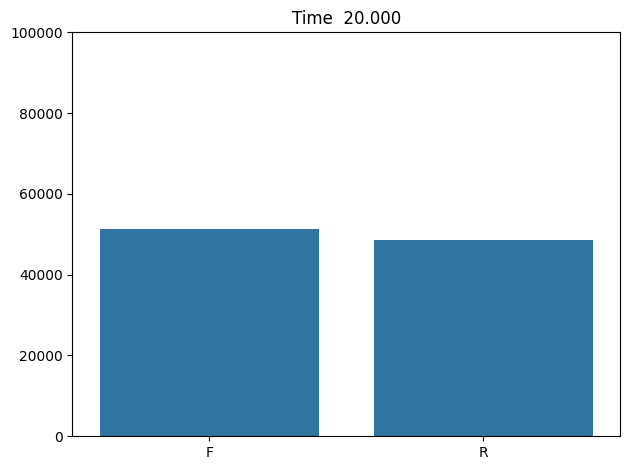

In [15]:
from batss.snapshot import StatePlotter

n = 10 ** 5
live = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=1)
live.add_snapshot(StatePlotter())
live.run(20.0, 0.1)

Once the run is done, `snapshot_slider` gives back a slider that moves every attached snapshot backwards
and forwards through the recorded history.

In [16]:
live.snapshot_slider('time')

interactive(children=(FloatSlider(value=0.0, description='time', layout=Layout(width='100%'), max=20.0, step=0…

## Sampling the distribution

A single run is just one sample from the CRN's distribution. `sample_future_configuration` restarts from the
current configuration many times over, and returns a `DataFrame` whose rows are the independent trials —
exactly the shape a histogram wants.

In [17]:
n = 10 ** 5
dist = Simulation({r: n // 2, f: n - n // 2}, rxns, seed=1)
samples = dist.sample_future_configuration(5.0, num_samples=500)
samples.describe().loc[['mean', 'std', 'min', 'max']]

  0%|          | 0/500 [00:00<?, ?it/s]

,F,R
mean,139652.244000,39507.468000
std,1067.444166,596.731402
min,136661.000000,37474.000000
max,143227.000000,41226.000000


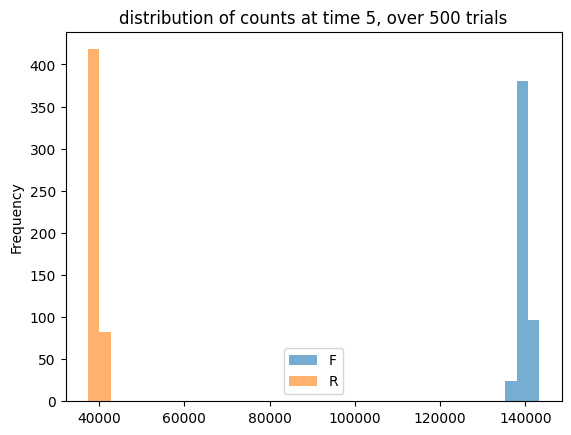

In [18]:
p = samples.plot(kind='hist', bins=40, alpha=0.6,
                 title='distribution of counts at time 5, over 500 trials')

## Time units

Rate constants usually come with physical units attached. `time_units` — any string that
`pandas.to_timedelta` accepts, such as `'seconds'` — makes the history index a pandas `TimedeltaIndex`, so
that plots are labelled in real time.

  0%|          | 0/20.0 [00:00<?, ? time simulated/s]

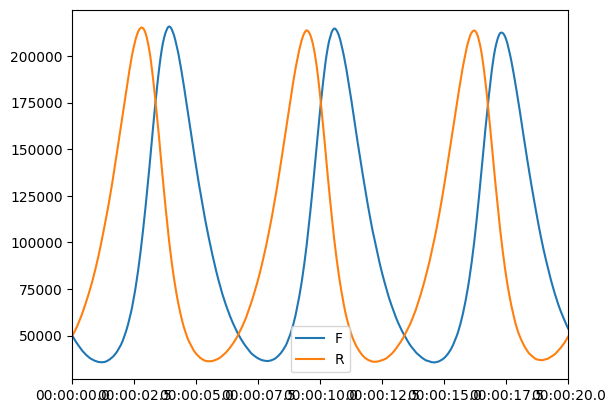

In [19]:
n = 10 ** 5
timed = Simulation({r: n // 2, f: n - n // 2}, rxns, time_units='seconds', seed=1)
timed.run(20.0, 0.05)
p = timed.history.plot()

## More examples

* [`examples/crn_examples.ipynb`](examples/crn_examples.ipynb) — the same tools applied to four more CRNs:
  dimerization, the Rössler-Willamowski attractor, the Oregonator, and the Brusselator.
* [`benchmark/benchmark.ipynb`](benchmark/benchmark.ipynb) — how batss's running time scales with the
  population size, measured against the Gillespie algorithm.
* [API documentation](https://batss.readthedocs.io/)